# Progetto parte 2 del corso di "Data Mining" da 12 CFU

### MODULE 0: Data Understanding & Preparation

*TIME SERIES DATASET*
* Perform exploratory analysis and describe your findings
* Pre-process the dataset to prepare it for tasks such as:
    * time-series clustering,
    * motif/anomaly detection
    * classification.
* If the dataset is too large for these tasks, consider using approximation (i.e., SAX, PAA).

---

### Informazioni Generali

* **Corso:** Data Mining
* **Università:** Università di Pisa
* **Anno Accademico:** 2024/2025

### Autore

* **Studente:** Giuseppe Muschetta
* **Matricola:** 564026

### Dataset Utilizzato

* **Nome:** Extended IMDb Dataset (Tabulare)
* **Descrizione:** Dataset tabulare contenente circa 150,000 record con informazioni relative ai titoli cinematografici.


In [1]:
# Import librerie standard
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.interpolate import interp1d
import os
import time
import warnings
warnings.filterwarnings('ignore')

# Import per time series
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# --- IMPOSTAZIONI GLOBALI PER I GRAFICI ---
# Stile base
plt.style.use("dark_background")
sns.set_theme(
    style="darkgrid",
    context="notebook",
    palette="icefire",
    font="sans-serif",
    font_scale=1.1
)

# Aggiornamenti avanzati
plt.rcParams.update({
    # Colori e sfondi
    'figure.facecolor': '#111111',
    'axes.facecolor': '#111111',
    'savefig.facecolor': '#111111',
    'axes.edgecolor': 'white',
    'axes.labelcolor': 'white',
    'axes.titlecolor': 'white',
    'text.color': 'white',
    'xtick.color': 'lightgray',
    'ytick.color': 'lightgray',

    # Font e peso
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',

    # Griglia elegante
    'axes.grid': True,
    'grid.color': 'gray',
    'grid.linestyle': '--',
    'grid.linewidth': 0.4,
    'grid.alpha': 0.3,  # meno invasiva

    # Tick leggeri
    'xtick.direction': 'out',
    'ytick.direction': 'out',

    # Leggibilità generale
    'legend.edgecolor': 'gray',
    'legend.facecolor': '#222222',
    'legend.fontsize': 'medium',
})

# plt.style.use('seaborn-v0_8-darkgrid')
# plt.rcParams['figure.figsize'] = (12, 6)
# plt.rcParams['font.size'] = 10

print("✅ Impostazioni grafiche caricate.")


# --- CREAZIONE DIRECTORY PER I MODELLI ---
print("--- Creazione directory per i modelli ---")
models_dir = 'models_time_series_understanding/'
os.makedirs(models_dir, exist_ok=True)
print(f"✅ Directory per i modelli '{models_dir}' pronta.")

# --- CREAZIONE DIRECTORY PER I PLOT ---
plots_dir = 'plots_time_series_understanding/'
os.makedirs(plots_dir, exist_ok=True)
print(f"✅ Directory per i grafici '{plots_dir}' pronta.")

# --- CARICAMENTO DEL DATASET PREPARATO ---
dataset_dir = "TS_Dataset/"
dataset_name = "imdb_ts.csv"
try:
    df = pd.read_csv(os.path.join(dataset_dir, dataset_name))
    print(f"✅ Dataset preparato caricato: {df.shape[0]} righe, {df.shape[1]} colonne.")
except FileNotFoundError as e:
    print(f"❌ Errore: File non trovato. Assicurati di aver eseguito il Modulo 0 e salvato '{dataset_name}'.")



✅ Impostazioni grafiche caricate.
--- Creazione directory per i modelli ---
✅ Directory per i modelli 'models_time_series_understanding/' pronta.
✅ Directory per i grafici 'plots_time_series_understanding/' pronta.
✅ Dataset preparato caricato: 1134 righe, 104 colonne.


#### PRIMA ESPLORAZIONE DEL DATASET

In [2]:
# Informazioni di base
print("=" * 50)
print("DATASET TIME SERIES - INFORMAZIONI DI BASE")
print("=" * 50)
print(f"Shape del dataset: {df.shape}")
print(f"Numero di film: {df.shape[0]}")
print(f"Numero di giorni: {df.shape[1] - 4}")  # Escludendo id, rating, genre, rating_category
print(f"\nColonne non-temporali: {df.columns[-4:].tolist()}")
print(f"\nTipi di dati:")
print(df.dtypes.value_counts())

# Mostra prime righe
print("\nPrime 5 righe del dataset:")
df.head()

DATASET TIME SERIES - INFORMAZIONI DI BASE
Shape del dataset: (1134, 104)
Numero di film: 1134
Numero di giorni: 100

Colonne non-temporali: ['99', 'rating', 'genre', 'rating_category']

Tipi di dati:
float64    101
object       3
Name: count, dtype: int64

Prime 5 righe del dataset:


,id,0,1,2,3,4,5,6,7,8,...,93,94,95,96,97,98,99,rating,genre,rating_category
0,tt0062622,57057.0,65469.0,71642.0,73025.0,74060.0,49472.0,30258.0,28036.0,25824.0,...,10709.0,11042.0,11388.0,11847.0,12404.0,13679.0,15056.0,8.3,"['Adventure', 'Sci-Fi']",High
1,tt0064816,1923.0,2422.0,2853.0,2947.0,3054.0,2844.0,2617.0,1998.0,1277.0,...,637.0,734.0,857.0,785.0,724.0,713.0,699.0,7.1,"['Crime', 'Drama', 'Romance']",High
2,tt0088178,332925.0,302503.0,267264.0,261879.0,256608.0,196530.0,112728.0,117384.0,123024.0,...,6784.0,7253.0,7776.0,9632.0,11212.0,9010.0,6431.0,8.7,"['Documentary', 'Music']",High
3,tt0145487,682857.0,407032.0,78058.0,81732.0,86772.0,83724.0,79940.0,39656.0,6974.0,...,21094.0,10995.0,1586.0,1421.0,1177.0,970.0,802.0,7.4,"['Action', 'Adventure', 'Sci-Fi']",High
4,tt0359950,7813372.0,6274563.0,4781588.0,4655046.0,4535301.0,4650574.0,4758452.0,4069428.0,3471755.0,...,88635.0,68347.0,45367.0,28915.0,15494.0,16155.0,16853.0,7.3,"['Adventure', 'Comedy', 'Drama']",High


In [3]:
# Sostituisci la colonna 'id' con numeri da 1 a N
df['id'] = range(1, len(df) + 1)

### Estrazione e Analisi delle Time Series

In [4]:
# Estrai solo le colonne temporali (giorni 0-99)
time_series_cols = [str(i) for i in range(100)]
ts_data = df[time_series_cols].values.astype(np.float32)  # float32 per efficienza

# Estrai metadata
metadata = df[['id', 'rating', 'genre', 'rating_category']]

# Statistiche di base sulle time series
print("STATISTICHE DELLE TIME SERIES")
print("=" * 50)

# Revenue totali per film
total_revenues = np.sum(ts_data, axis=1)
print(f"\nRevenue Totale - Statistiche:")
print(f"  Media: ${total_revenues.mean():,.2f}")
print(f"  Mediana: ${np.median(total_revenues):,.2f}")
print(f"  Std Dev: ${total_revenues.std():,.2f}")
print(f"  Min: ${total_revenues.min():,.2f}")
print(f"  Max: ${total_revenues.max():,.2f}")

# Analisi degli zeri
zeros_per_film = np.sum(ts_data == 0, axis=1)
print(f"\nAnalisi degli zeri:")
print(f"  Film con almeno uno zero: {np.sum(zeros_per_film > 0)} ({np.sum(zeros_per_film > 0)/len(df)*100:.1f}%)")
print(f"  Media zeri per film: {zeros_per_film.mean():.1f}")
print(f"  Film con tutti zeri: {np.sum(zeros_per_film == 100)}")

# Longevità (giorni con revenue > 0)
longevity = 100 - zeros_per_film
print(f"\nLongevità in sala (giorni con revenue > 0):")
print(f"  Media: {longevity.mean():.1f} giorni")
print(f"  Mediana: {np.median(longevity):.1f} giorni")
print(f"  Min: {longevity.min()} giorni")
print(f"  Max: {longevity.max()} giorni")

STATISTICHE DELLE TIME SERIES

Revenue Totale - Statistiche:
  Media: $146,807,424.00
  Mediana: $75,853,664.00
  Std Dev: $209,855,424.00
  Min: $139,777.00
  Max: $1,763,034,752.00

Analisi degli zeri:
  Film con almeno uno zero: 0 (0.0%)
  Media zeri per film: 0.0
  Film con tutti zeri: 0

Longevità in sala (giorni con revenue > 0):
  Media: 100.0 giorni
  Mediana: 100.0 giorni
  Min: 100 giorni
  Max: 100 giorni


### Visualizzazione Pattern Globali

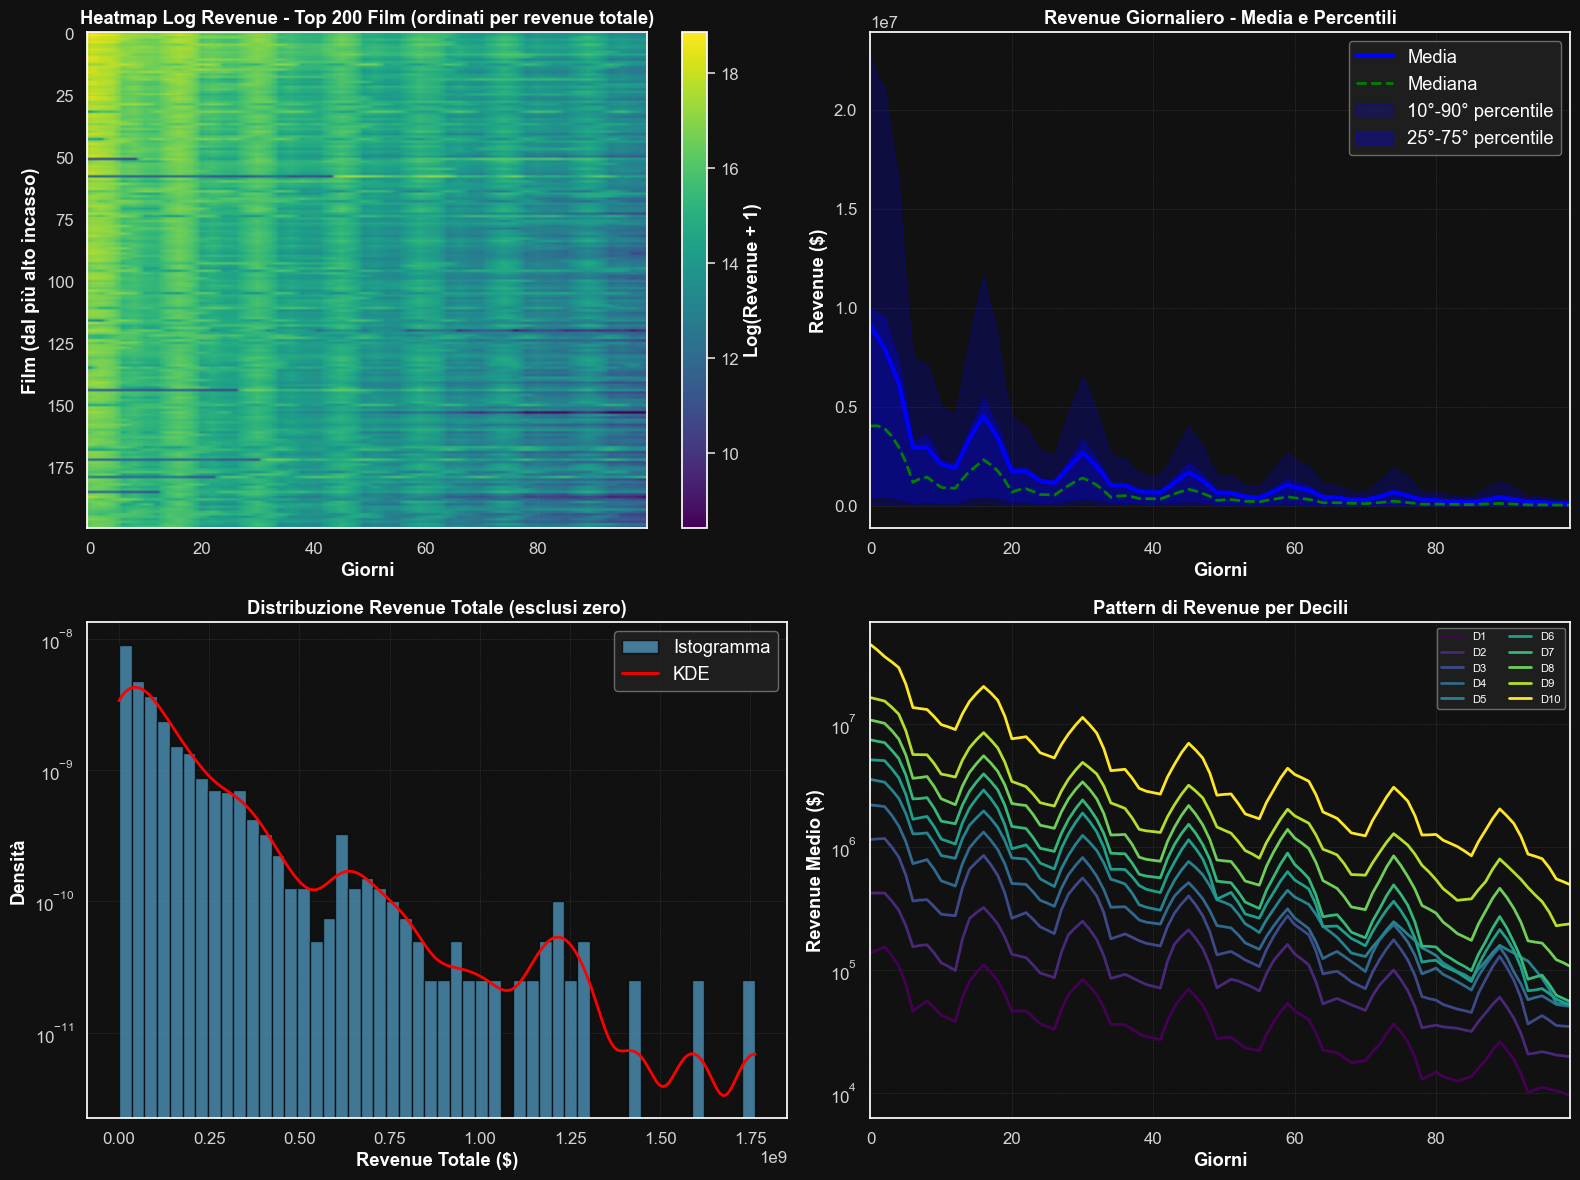

In [5]:
# Crea figure per visualizzazioni multiple
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Heatmap di TUTTI i film (grazie alla RAM abbondante!)
ax1 = axes[0, 0]
# Ordina i film per revenue totale per una visualizzazione più informativa
sorted_indices = np.argsort(total_revenues)[::-1]
sorted_data = ts_data[sorted_indices]

im = ax1.imshow(np.log1p(sorted_data[:200]), aspect='auto', cmap='viridis')  # Top 200 per leggibilità
ax1.set_title('Heatmap Log Revenue - Top 200 Film (ordinati per revenue totale)')
ax1.set_xlabel('Giorni')
ax1.set_ylabel('Film (dal più alto incasso)')
plt.colorbar(im, ax=ax1, label='Log(Revenue + 1)')

# 2. Revenue medio per giorno con percentili
ax2 = axes[0, 1]
daily_mean = np.mean(ts_data, axis=0)
daily_percentiles = np.percentile(ts_data, [10, 25, 50, 75, 90], axis=0)
days = np.arange(100)

ax2.plot(days, daily_mean, 'b-', linewidth=3, label='Media')
ax2.plot(days, daily_percentiles[2], 'g--', linewidth=2, label='Mediana')
ax2.fill_between(days, daily_percentiles[0], daily_percentiles[4],
                  alpha=0.2, color='blue', label='10°-90° percentile')
ax2.fill_between(days, daily_percentiles[1], daily_percentiles[3],
                  alpha=0.3, color='blue', label='25°-75° percentile')
ax2.set_title('Revenue Giornaliero - Media e Percentili')
ax2.set_xlabel('Giorni')
ax2.set_ylabel('Revenue ($)')
ax2.legend()
ax2.set_xlim(0, 99)

# 3. Distribuzione del revenue totale con KDE
ax3 = axes[1, 0]
ax3.hist(total_revenues[total_revenues > 0], bins=50, edgecolor='black',
         alpha=0.7, density=True, label='Istogramma')
# Aggiungi KDE
from scipy.stats import gaussian_kde
kde = gaussian_kde(total_revenues[total_revenues > 0])
x_range = np.linspace(0, total_revenues.max(), 200)
ax3.plot(x_range, kde(x_range), 'r-', linewidth=2, label='KDE')
ax3.set_title('Distribuzione Revenue Totale (esclusi zero)')
ax3.set_xlabel('Revenue Totale ($)')
ax3.set_ylabel('Densità')
ax3.set_yscale('log')
ax3.legend()

# 4. Pattern di decadimento per decili (più granulare)
ax4 = axes[1, 1]
deciles = np.percentile(total_revenues[total_revenues > 0], np.arange(10, 100, 10))
colors = plt.cm.viridis(np.linspace(0, 1, 10))

for i in range(10):
    low = 0 if i == 0 else deciles[i-1]
    high = total_revenues.max() if i == 9 else deciles[i]

    mask = (total_revenues > low) & (total_revenues <= high)
    if np.sum(mask) > 0:
        decile_data = ts_data[mask]
        mean_pattern = np.mean(decile_data, axis=0)
        ax4.plot(days, mean_pattern, label=f'D{i+1}', color=colors[i], linewidth=2)

ax4.set_title('Pattern di Revenue per Decili')
ax4.set_xlabel('Giorni')
ax4.set_ylabel('Revenue Medio ($)')
ax4.legend(ncol=2, fontsize=8)
ax4.set_xlim(0, 99)
ax4.set_yscale('log')
plt.tight_layout()
plt.savefig(plots_dir + "ts_pattern_globali", dpi=300, bbox_inches='tight')
plt.show()

### Analisi dei pattern settimanali

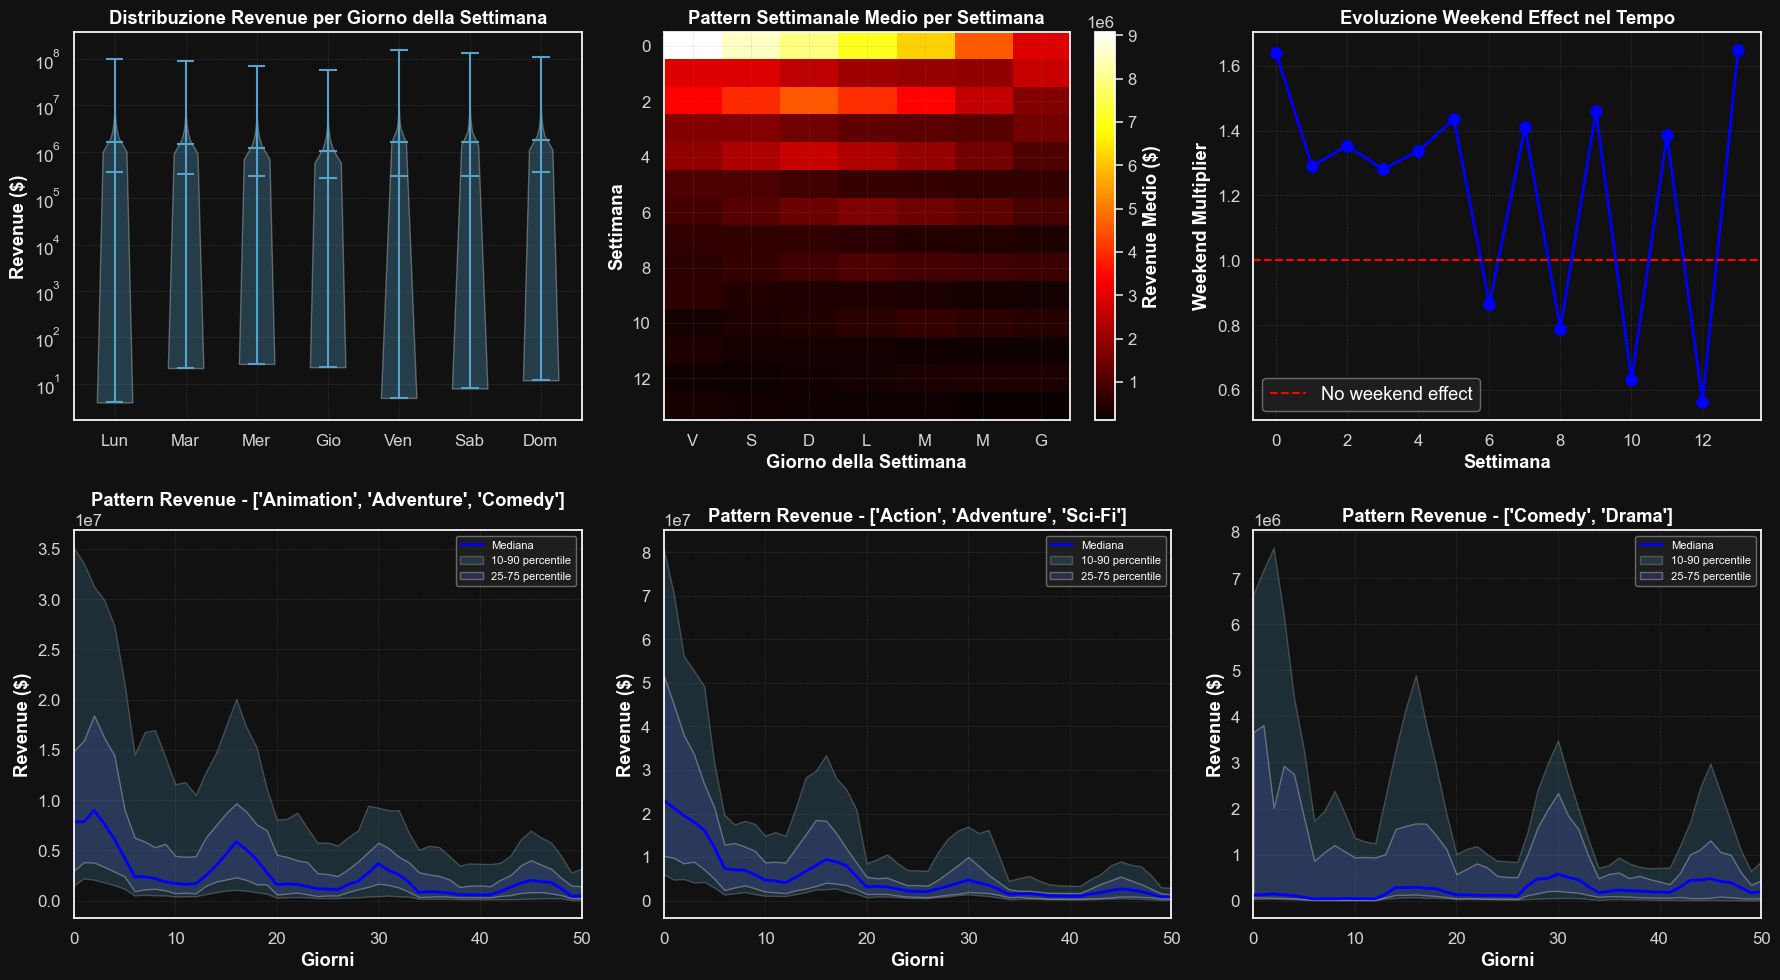

In [6]:
# Analisi avanzata del weekend effect
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Revenue per giorno della settimana - distribuzione completa
ax1 = axes[0, 0]
day_of_week_revenue = []
day_names = ['Lun', 'Mar', 'Mer', 'Gio', 'Ven', 'Sab', 'Dom']

for dow in range(7):
    dow_indices = [i for i in range(100) if (i + 4) % 7 == dow]  # +4 perché parte da venerdì
    dow_revenue = ts_data[:, dow_indices].flatten()
    dow_revenue = dow_revenue[dow_revenue > 0]  # Escludi zeri
    day_of_week_revenue.append(dow_revenue)

parts = ax1.violinplot(day_of_week_revenue, positions=range(7),
                       showmeans=True, showmedians=True)
ax1.set_xticks(range(7))
ax1.set_xticklabels(day_names)
ax1.set_title('Distribuzione Revenue per Giorno della Settimana')
ax1.set_ylabel('Revenue ($)')
ax1.set_yscale('log')

# 2. Heatmap pattern settimanale per settimana
ax2 = axes[0, 1]
weeks_data = []
for week in range(14):  # Prime 14 settimane
    week_start = week * 7
    week_end = min((week + 1) * 7, 100)
    if week_end <= 100:
        week_revenue = np.mean(ts_data[:, week_start:week_end], axis=0)
        if len(week_revenue) == 7:
            weeks_data.append(week_revenue)

weeks_data = np.array(weeks_data)
im = ax2.imshow(weeks_data, aspect='auto', cmap='hot')
ax2.set_xlabel('Giorno della Settimana')
ax2.set_ylabel('Settimana')
ax2.set_xticks(range(7))
ax2.set_xticklabels(['V', 'S', 'D', 'L', 'M', 'M', 'G'])
ax2.set_title('Pattern Settimanale Medio per Settimana')
plt.colorbar(im, ax=ax2, label='Revenue Medio ($)')

# 3. Weekend multiplier per settimana
ax3 = axes[0, 2]
weekend_multipliers = []
for week in range(14):
    week_start = week * 7
    week_end = min((week + 1) * 7, 100)

    weekend_days = [i for i in range(week_start, week_end) if (i + 4) % 7 in [4, 5, 6]]
    weekday_days = [i for i in range(week_start, week_end) if (i + 4) % 7 in [0, 1, 2, 3]]

    if weekend_days and weekday_days:
        weekend_avg = np.mean(ts_data[:, weekend_days])
        weekday_avg = np.mean(ts_data[:, weekday_days])
        if weekday_avg > 0:
            multiplier = weekend_avg / weekday_avg
            weekend_multipliers.append(multiplier)

ax3.plot(range(len(weekend_multipliers)), weekend_multipliers, 'bo-', linewidth=2, markersize=8)
ax3.axhline(y=1, color='red', linestyle='--', label='No weekend effect')
ax3.set_xlabel('Settimana')
ax3.set_ylabel('Weekend Multiplier')
ax3.set_title('Evoluzione Weekend Effect nel Tempo')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4-6. Analisi per genere (bottom row)
top_genres = metadata['genre'].value_counts().head(6).index

for idx, genre in enumerate(top_genres[:3]):
    ax = axes[1, idx]
    genre_mask = metadata['genre'] == genre
    genre_data = ts_data[genre_mask]

    # Plot percentili
    percentiles = np.percentile(genre_data, [10, 25, 50, 75, 90], axis=0)
    ax.plot(percentiles[2], 'b-', linewidth=2, label='Mediana')
    ax.fill_between(range(100), percentiles[0], percentiles[4],
                    alpha=0.2, label='10-90 percentile')
    ax.fill_between(range(100), percentiles[1], percentiles[3],
                    alpha=0.3, label='25-75 percentile')

    ax.set_title(f'Pattern Revenue - {genre}')
    ax.set_xlabel('Giorni')
    ax.set_ylabel('Revenue ($)')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 50)  # Focus primi 50 giorni

plt.tight_layout()
plt.show()

### Analisi avanzata dei pattern di decadimento

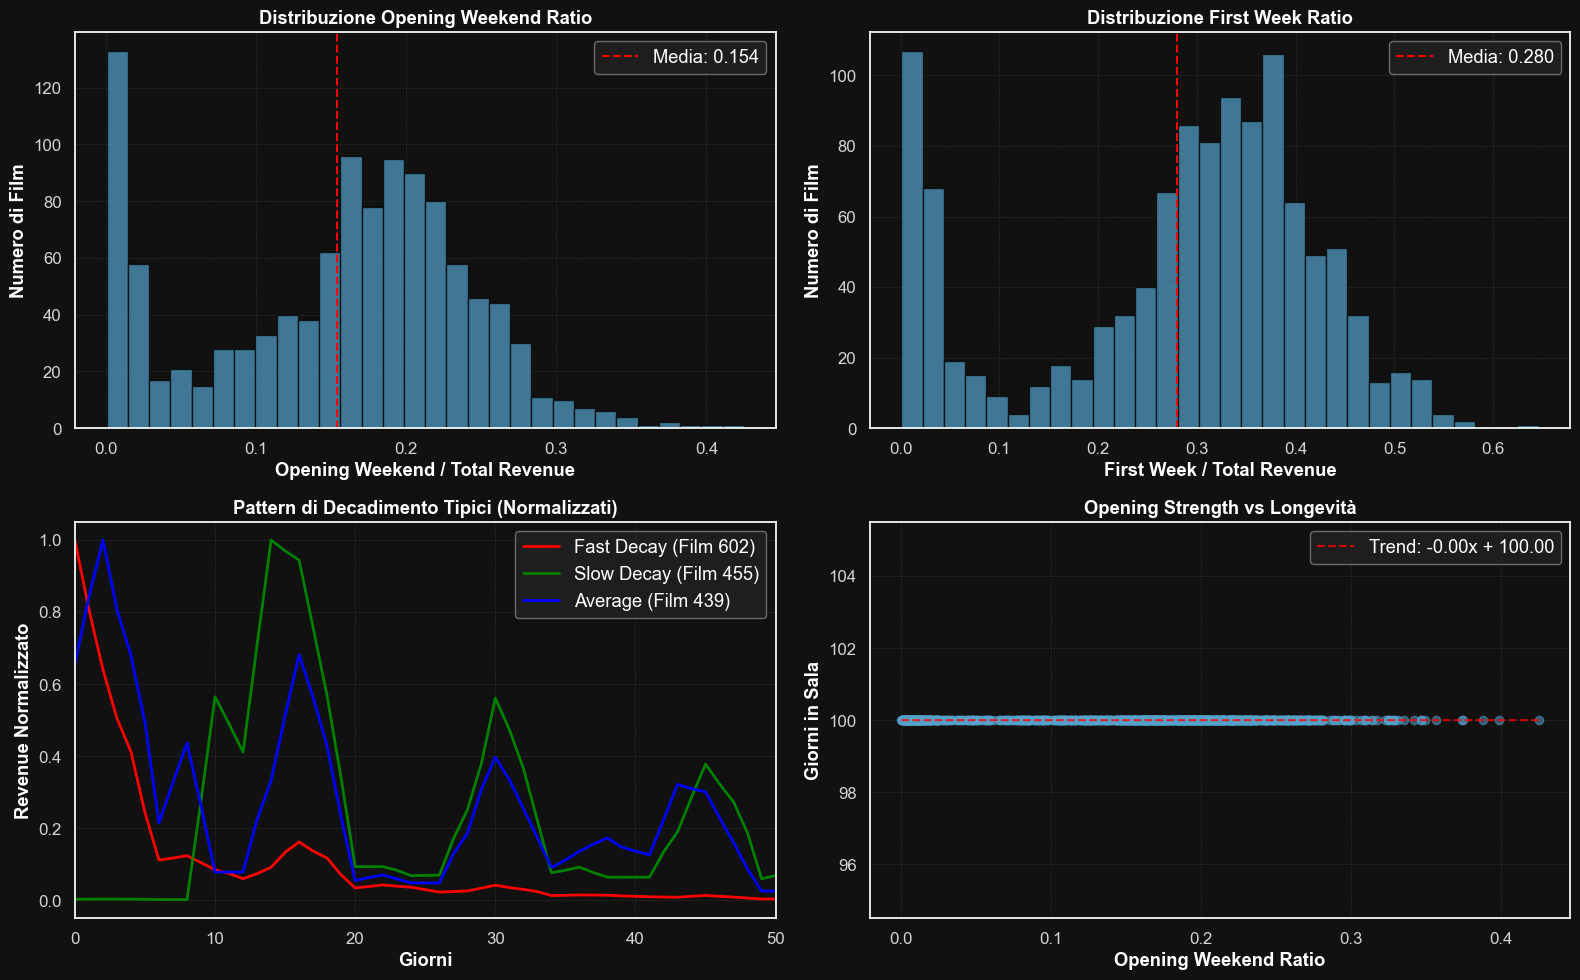

Correlazione tra Opening Ratio e Longevità: nan


In [7]:
# Calcola metriche di decadimento per ogni film
opening_weekend = np.sum(ts_data[:, :3], axis=1)  # Primi 3 giorni
first_week = np.sum(ts_data[:, :7], axis=1)       # Prima settimana
second_week = np.sum(ts_data[:, 7:14], axis=1)    # Seconda settimana

# Ratios
opening_ratio = opening_weekend / (total_revenues + 1e-10)
first_week_ratio = first_week / (total_revenues + 1e-10)
second_week_drop = (first_week - second_week) / (first_week + 1e-10)

# Visualizza
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Opening weekend strength
ax1 = axes[0, 0]
ax1.hist(opening_ratio, bins=30, edgecolor='black', alpha=0.7)
ax1.set_title('Distribuzione Opening Weekend Ratio')
ax1.set_xlabel('Opening Weekend / Total Revenue')
ax1.set_ylabel('Numero di Film')
ax1.axvline(opening_ratio.mean(), color='red', linestyle='--',
            label=f'Media: {opening_ratio.mean():.3f}')
ax1.legend()

# 2. First week importance
ax2 = axes[0, 1]
ax2.hist(first_week_ratio, bins=30, edgecolor='black', alpha=0.7)
ax2.set_title('Distribuzione First Week Ratio')
ax2.set_xlabel('First Week / Total Revenue')
ax2.set_ylabel('Numero di Film')
ax2.axvline(first_week_ratio.mean(), color='red', linestyle='--',
            label=f'Media: {first_week_ratio.mean():.3f}')
ax2.legend()

# 3. Decay patterns - esempi rappresentativi
ax3 = axes[1, 0]
# Trova film rappresentativi per diversi pattern
fast_decay_idx = np.argmax(opening_ratio)  # Massimo opening ratio
slow_decay_idx = np.argmin(second_week_drop[second_week > 0])  # Minimo drop
average_idx = np.argmin(np.abs(opening_ratio - opening_ratio.mean()))  # Più vicino alla media

for idx, label, color in [(fast_decay_idx, 'Fast Decay', 'red'),
                          (slow_decay_idx, 'Slow Decay', 'green'),
                          (average_idx, 'Average', 'blue')]:
    normalized_revenue = ts_data[idx] / ts_data[idx].max()
    ax3.plot(normalized_revenue, label=f'{label} (Film {metadata.iloc[idx]["id"]})',
             color=color, linewidth=2)

ax3.set_title('Pattern di Decadimento Tipici (Normalizzati)')
ax3.set_xlabel('Giorni')
ax3.set_ylabel('Revenue Normalizzato')
ax3.legend()
ax3.set_xlim(0, 50)  # Focus sui primi 50 giorni

# 4. Scatter plot: Opening vs Longevity
ax4 = axes[1, 1]
ax4.scatter(opening_ratio, longevity, alpha=0.5)
ax4.set_xlabel('Opening Weekend Ratio')
ax4.set_ylabel('Giorni in Sala')
ax4.set_title('Opening Strength vs Longevità')

# Aggiungi linea di tendenza
z = np.polyfit(opening_ratio, longevity, 1)
p = np.poly1d(z)
ax4.plot(np.sort(opening_ratio), p(np.sort(opening_ratio)),
         "r--", alpha=0.8, label=f'Trend: {z[0]:.2f}x + {z[1]:.2f}')
ax4.legend()

plt.tight_layout()
plt.show()

# Calcola correlazione
corr = np.corrcoef(opening_ratio, longevity)[0, 1]
print(f"Correlazione tra Opening Ratio e Longevità: {corr:.3f}")

### Feature Engineering avanzato

Feature estratte dalle time series:
       total_revenue  opening_weekend    first_week  second_week  \
count   1.134000e+03     1.134000e+03  1.134000e+03       1134.0   
mean    1.468074e+08     2.555105e+07  4.634346e+07   17011950.0   
std     2.099480e+08     4.093849e+07  7.207241e+07   27255146.0   
min     1.397770e+05     7.198000e+03  1.866000e+04      11021.0   
25%     2.559038e+07     1.364089e+06  2.614553e+06    1341520.0   
50%     7.585367e+07     1.214178e+07  2.263758e+07    8221982.0   
75%     1.774138e+08     2.919651e+07  5.473264e+07   19643806.0   
max     1.763035e+09     4.012790e+08  6.958413e+08  251863520.0   

       opening_ratio  first_week_ratio  week2_drop  peak_day  peak_revenue  \
count        1134.00           1134.00     1134.00   1134.00  1.134000e+03   
mean            0.15              0.28        0.32      8.95  1.005232e+07   
std             0.09              0.14        4.04     17.07  1.562452e+07   
min             0.00              0.00 

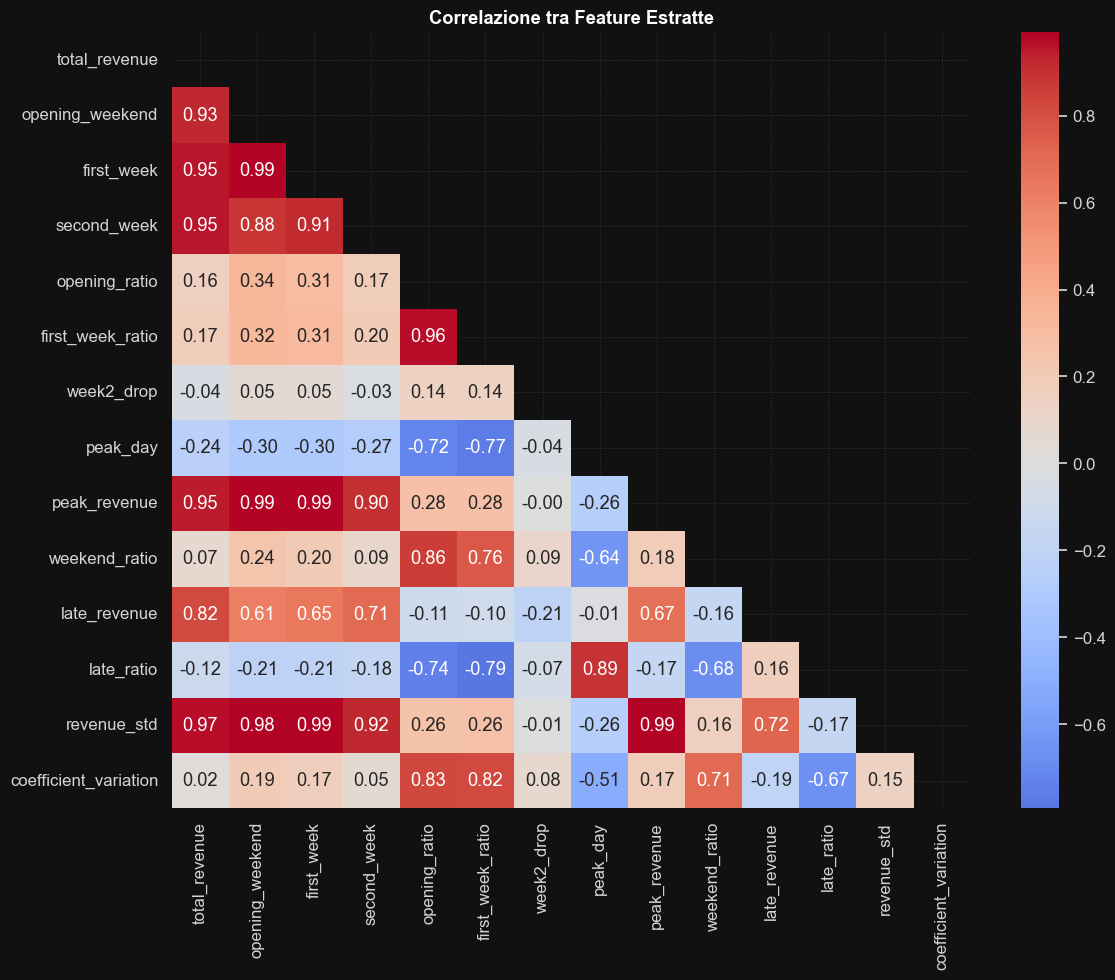

In [15]:
# Estrai feature interpretabili dalle time series
def extract_ts_features(ts_data):
    """Estrae feature interpretabili dalle time series di box office"""
    n_films = len(ts_data)
    features = {}

    # Revenue-based features
    features['total_revenue'] = np.sum(ts_data, axis=1)
    features['opening_weekend'] = np.sum(ts_data[:, :3], axis=1)
    features['first_week'] = np.sum(ts_data[:, :7], axis=1)
    features['second_week'] = np.sum(ts_data[:, 7:14], axis=1)

    # Ratio features
    features['opening_ratio'] = features['opening_weekend'] / (features['total_revenue'] + 1e-10)
    features['first_week_ratio'] = features['first_week'] / (features['total_revenue'] + 1e-10)

    # Decay features
    features['week2_drop'] = (features['first_week'] - features['second_week']) / (features['first_week'] + 1e-10)

    # Peak and sustainability
    features['peak_day'] = np.argmax(ts_data, axis=1)
    features['peak_revenue'] = np.max(ts_data, axis=1)

    # Weekend effect
    weekend_indices = [i for i in range(100) if (i + 4) % 7 in [4, 5, 6]]
    weekday_indices = [i for i in range(100) if (i + 4) % 7 in [0, 1, 2, 3]]
    weekend_rev = np.sum(ts_data[:, weekend_indices], axis=1)
    weekday_rev = np.sum(ts_data[:, weekday_indices], axis=1)
    features['weekend_ratio'] = weekend_rev / (weekend_rev + weekday_rev + 1e-10)

    # Late performance
    features['late_revenue'] = np.sum(ts_data[:, 50:], axis=1)
    features['late_ratio'] = features['late_revenue'] / (features['total_revenue'] + 1e-10)

    # Volatility
    features['revenue_std'] = np.std(ts_data, axis=1)
    features['coefficient_variation'] = features['revenue_std'] / (np.mean(ts_data, axis=1) + 1e-10)

    return pd.DataFrame(features)

# Estrai features
ts_features = extract_ts_features(ts_data)
print("Feature estratte dalle time series:")
print(ts_features.describe().round(2))

# Visualizza correlazioni tra features - solo triangolo inferiore
plt.figure(figsize=(12, 10))
correlation_matrix = ts_features.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlazione tra Feature Estratte')
plt.tight_layout()
plt.savefig(plots_dir + "features_engineered_correlations", dpi=300, bbox_inches='tight')
plt.show()

### Preprocessing e Normalizzazione

In [ ]:
# Crea multiple rappresentazioni normalizzate delle time series

print("Creazione rappresentazioni normalizzate...")

# 1. Raw data (originale)
ts_raw = ts_data.copy()

# 2. Log-transformed (stabilizza varianza mantenendo forma)
ts_log = np.log1p(ts_data)

# 3. Percentage normalized (ogni film somma a 100)
ts_percentage = np.zeros_like(ts_data, dtype=np.float32)
for i in range(len(ts_data)):
    total = ts_data[i].sum()
    if total > 0:
        ts_percentage[i] = (ts_data[i] / total) * 100
    else:
        ts_percentage[i] = ts_data[i]

# 4. Z-score normalized per film
ts_zscore_film = np.zeros_like(ts_data, dtype=np.float32)
for i in range(len(ts_data)):
    series = ts_data[i]
    if series.std() > 0:
        ts_zscore_film[i] = (series - series.mean()) / series.std()
    else:
        ts_zscore_film[i] = 0

# 5. Min-Max scaled per film
ts_minmax_film = np.zeros_like(ts_data, dtype=np.float32)
for i in range(len(ts_data)):
    series = ts_data[i]
    min_val = series.min()
    max_val = series.max()
    if max_val > min_val:
        ts_minmax_film[i] = (series - min_val) / (max_val - min_val)
    else:
        ts_minmax_film[i] = 0

# 6. Z-score normalized globalmente (per confronti cross-film)
global_mean = ts_data.mean()
global_std = ts_data.std()
ts_zscore_global = (ts_data - global_mean) / global_std

print("\nRappresentazioni create:")
print(f"1. ts_raw: shape {ts_raw.shape} - Dati originali")
print(f"2. ts_log: shape {ts_log.shape} - Log-transformed")
print(f"3. ts_percentage: shape {ts_percentage.shape} - Percentuale del totale")
print(f"4. ts_zscore_film: shape {ts_zscore_film.shape} - Z-score per film")
print(f"5. ts_minmax_film: shape {ts_minmax_film.shape} - Min-Max per film")
print(f"6. ts_zscore_global: shape {ts_zscore_global.shape} - Z-score globale")

# Visualizza l'effetto delle normalizzazioni
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Seleziona un film rappresentativo
example_idx = np.argsort(total_revenues)[len(total_revenues)//2]  # Mediano

normalizations = [
    (ts_raw[example_idx], 'Raw Data', 'blue'),
    (ts_log[example_idx], 'Log-transformed', 'green'),
    (ts_percentage[example_idx], 'Percentage', 'red'),
    (ts_zscore_film[example_idx], 'Z-score (Film)', 'purple'),
    (ts_minmax_film[example_idx], 'Min-Max (Film)', 'orange'),
    (ts_zscore_global[example_idx], 'Z-score (Global)', 'brown')
]

for idx, (data, title, color) in enumerate(normalizations):
    ax = axes[idx]
    ax.plot(data, color=color, linewidth=2)
    ax.set_title(f'{title}')
    ax.set_xlabel('Days')
    ax.set_ylabel('Value')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 99)

plt.suptitle(f'Effetto delle Normalizzazioni - Film {metadata.iloc[example_idx]["id"]}', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
"""
| Task                              | Dataset consigliato                                                   |
| --------------------------------- | --------------------------------------------------------------------- |
| **Motif Discovery**               | `ts_log` o `ts_normalized`                                            |
| **Discord Detection**             | `ts_log` (se vuoi ridurre outlier) oppure `ts_raw` (se vuoi trovarli) |
| **Clustering (KMeans, DTW, etc)** | `ts_zscore` o `ts_normalized`                                         |
| **Shapelet-based Classification** | `ts_normalized`                                                       |
| **Regressione su rating/revenue** | `ts_raw` o `ts_log`                                                   |
| **Visualizzazione (PCA/UMAP)**    | `ts_zscore`                                                           |

"""

### PREPARAZIONE DATASET PER TASK SUCCESSIVI

In [ ]:
# Prepara dataset specifici per ogni task ML

print("Preparazione dataset per task di ML...")

# === 1. DATASET PER CLUSTERING ===
clustering_datasets = {
    'full_raw': ts_raw,                    # Serie complete raw
    'full_log': ts_log,                    # Serie complete log-transformed
    'full_percentage': ts_percentage,       # Serie complete normalizzate %
    'full_zscore': ts_zscore_film,         # Serie complete z-score
    'features_only': ts_features.values,   # Solo features estratte
    'combined_log_features': np.hstack([   # Combinazione serie + features
        ts_log,
        StandardScaler().fit_transform(ts_features.values)
    ])
}

print("\n1. CLUSTERING datasets pronti:")
for name, data in clustering_datasets.items():
    print(f"   - {name}: shape {data.shape}")

# === 2. DATASET PER CLASSIFICATION ===
# Target 1: Success level basato su revenue
revenue_percentiles = np.percentile(total_revenues[total_revenues > 0], [20, 40, 60, 80])
revenue_success = np.zeros(len(df))
for i, rev in enumerate(total_revenues):
    if rev == 0:
        revenue_success[i] = 0  # No revenue
    elif rev <= revenue_percentiles[0]:
        revenue_success[i] = 1  # Very Low
    elif rev <= revenue_percentiles[1]:
        revenue_success[i] = 2  # Low
    elif rev <= revenue_percentiles[2]:
        revenue_success[i] = 3  # Medium
    elif rev <= revenue_percentiles[3]:
        revenue_success[i] = 4  # High
    else:
        revenue_success[i] = 5  # Very High

# Target 2: Pattern type
pattern_type = []
for i in range(len(ts_data)):
    if total_revenues[i] == 0:
        pattern_type.append(0)  # No revenue
    elif opening_ratio[i] > 0.5:
        pattern_type.append(1)  # Front-loaded
    elif ts_features['days_to_50_percent'][i] > 30:
        pattern_type.append(2)  # Slow burn
    elif ts_features['has_late_surge'][i] == 1:
        pattern_type.append(3)  # Late surge
    else:
        pattern_type.append(4)  # Standard

pattern_type = np.array(pattern_type)

classification_datasets = {
    'X_full': ts_log,                      # Full time series log
    'X_zscore': ts_zscore_film,            # Full time series z-score
    'X_features': ts_features.values,      # Engineered features only
    'X_combined': np.hstack([              # Combined representation
        ts_log,
        StandardScaler().fit_transform(ts_features.values)
    ]),
    'y_revenue_success': revenue_success,   # Revenue-based target
    'y_pattern_type': pattern_type,        # Pattern-based target
    'y_rating': metadata['rating_category'].values,  # Original rating
    'y_genre': metadata['genre'].values    # Genre (for stratification)
}

print("\n2. CLASSIFICATION datasets pronti:")
for name, data in classification_datasets.items():
    if name.startswith('X'):
        print(f"   - {name}: shape {data.shape}")
    else:
        unique_values = len(np.unique(data))
        print(f"   - {name}: {unique_values} unique classes")

# === 3. DATASET PER MOTIF/ANOMALY DETECTION ===
motif_datasets = {
    'series_raw': ts_raw,              # Raw per pattern naturali
    'series_log': ts_log,              # Log per stabilità numerica
    'series_zscore': ts_zscore_film,   # Z-score per anomaly detection
    'metadata': metadata,              # Per interpretazione
    'features': ts_features            # Per anomaly detection feature-based
}

print("\n3. MOTIF/ANOMALY datasets pronti:")
for name, data in motif_datasets.items():
    if hasattr(data, 'shape'):
        print(f"   - {name}: shape {data.shape}")

# === SALVA TUTTI I DATASET ===
import pickle

# Dataset principale preprocessato
preprocessed_data = {
    'original': df,
    'time_series': {
        'raw': ts_raw,
        'log': ts_log,
        'percentage': ts_percentage,
        'zscore_film': ts_zscore_film,
        'zscore_global': ts_zscore_global,
        'minmax': ts_minmax_film
    },
    'features': ts_features,
    'metadata': metadata,
    'info': {
        'n_films': len(df),
        'n_days': 100,
        'n_features': len(ts_features.columns),
        'memory_usage_mb': df.memory_usage(deep=True).sum() / 1024 / 1024
    }
}

# Dataset task-specific
task_datasets = {
    'clustering': clustering_datasets,
    'classification': classification_datasets,
    'motif': motif_datasets
}

# Salva su disco
with open('preprocessed_timeseries_full.pkl', 'wb') as f:
    pickle.dump(preprocessed_data, f)

with open('task_datasets_full.pkl', 'wb') as f:
    pickle.dump(task_datasets, f)

print("\n✅ Tutti i dataset salvati!")
print(f"   - preprocessed_timeseries_full.pkl")
print(f"   - task_datasets_full.pkl")

#### Report Finale e Visualizzazione Summary

In [ ]:
# Report riassuntivo finale

print("=" * 80)
print("TIME SERIES ANALYSIS - FINAL SUMMARY REPORT")
print("=" * 80)

print("\n📊 DATASET OVERVIEW:")
print(f"- Total films analyzed: {len(df):,}")
print(f"- Time series length: 100 days each")
print(f"- Total data points: {len(df) * 100:,}")
print(f"- Memory usage: {df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB")
print(f"- Additional metadata: rating ({metadata['rating'].nunique()} unique), "
      f"genre ({metadata['genre'].nunique()} unique), rating_category")

print("\n🎬 KEY INSIGHTS:")
print(f"- Opening weekend accounts for {(opening_ratio.mean()*100):.1f}% of total revenue on average")
print(f"- {np.sum(ts_features['has_late_surge'])}/{len(df)} films "
      f"({np.mean(ts_features['has_late_surge'])*100:.1f}%) show late surge patterns")
print(f"- Weekend revenue is {((ts_features['weekend_revenue_ratio'].mean()-0.5)*100):.1f}% higher than expected")
print(f"- Average film stays in theaters for {longevity.mean():.1f} days")
print(f"- {np.sum(total_revenues == 0)} films have zero revenue")

print("\n🔧 PREPROCESSING COMPLETED:")
print("1. Created 6 normalized representations:")
print("   - Raw, Log-transformed, Percentage, Z-score (film), Min-Max, Z-score (global)")
print("2. Extracted 30+ interpretable features")
print("3. No dimensionality reduction applied (using full 100-day series)")

print("\n📁 DATASETS PREPARED:")
print(f"- Clustering: {len(clustering_datasets)} different representations")
print(f"- Classification: {len([k for k in classification_datasets if k.startswith('X')])} "
      f"feature sets, {len([k for k in classification_datasets if k.startswith('y')])} targets")
print(f"- Motif/Anomaly: {len(motif_datasets)} datasets ready")

print("\n💡 RECOMMENDED NEXT STEPS:")
print("1. Clustering: Start with ts_log or ts_percentage for DTW-based clustering")
print("2. Classification: Use combined features+series for best results")
print("3. Motif Detection: Apply Matrix Profile on ts_log")
print("4. Consider genre-specific analysis for deeper insights")

# Visualizzazione summary finale
fig = plt.figure(figsize=(20, 12))

# Create grid
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# 1. Top grossing films pattern
ax1 = fig.add_subplot(gs[0, :2])
top_10_idx = np.argsort(total_revenues)[-10:][::-1]
for i, idx in enumerate(top_10_idx):
    ax1.plot(ts_log[idx], alpha=0.7, label=f"{metadata.iloc[idx]['genre'][:10]}")
ax1.set_title('Top 10 Films - Log Revenue Patterns')
ax1.set_xlabel('Days')
ax1.set_ylabel('Log Revenue')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# 2. Feature correlation heatmap
ax2 = fig.add_subplot(gs[0, 2:])
key_features = ['opening_weekend_ratio', 'decay_rate', 'days_in_theater',
                'weekend_multiplier', 'peak_day', 'has_late_surge']
corr_matrix = ts_features[key_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax2, cbar_kws={'shrink': 0.8})
ax2.set_title('Key Features Correlation Matrix')

# 3. Genre performance
ax3 = fig.add_subplot(gs[1, :2])
genre_revenue = metadata.groupby('genre').apply(
    lambda x: total_revenues[x.index].mean()
).sort_values(ascending=False).head(10)
ax3.barh(range(len(genre_revenue)), genre_revenue.values)
ax3.set_yticks(range(len(genre_revenue)))
ax3.set_yticklabels(genre_revenue.index)
ax3.set_xlabel('Average Total Revenue ($)')
ax3.set_title('Top 10 Genres by Average Revenue')

# 4. Pattern classification distribution
ax4 = fig.add_subplot(gs[1, 2])
pattern_counts = pd.Series(pattern_type).value_counts().sort_index()
pattern_label_map = {
    0: 'No Revenue',
    1: 'Front-loaded',
    2: 'Slow Burn',
    3: 'Late Surge',
    4: 'Standard'
}
pattern_labels = [pattern_label_map[k] for k in pattern_counts.index]

ax4.pie(pattern_counts.values, labels=pattern_labels, autopct='%1.1f%%')
ax4.set_title('Distribution of Revenue Patterns')


# 5. Success distribution
ax5 = fig.add_subplot(gs[1, 3])
# Mappa dinamica basata sui livelli presenti nei dati
success_label_map = {
    0: 'No Rev',
    1: 'Very Low',
    2: 'Low',
    3: 'Medium',
    4: 'High',
    5: 'Very High'
}
success_counts = pd.Series(revenue_success).value_counts().sort_index()
success_labels = [success_label_map[k] for k in success_counts.index]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(success_labels)))
ax5.bar(range(len(success_counts)), success_counts.values, color=colors)
ax5.set_xticks(range(len(success_counts)))
ax5.set_xticklabels(success_labels, rotation=45)
ax5.set_ylabel('Count')
ax5.set_title('Revenue Success Distribution')

# 6. Time series length distribution (days in theater)
ax6 = fig.add_subplot(gs[2, :2])
ax6.hist(longevity[longevity > 0], bins=50, edgecolor='black', alpha=0.7)
ax6.axvline(longevity.mean(), color='red', linestyle='--',
            label=f'Mean: {longevity.mean():.1f} days')
ax6.set_xlabel('Days in Theater')
ax6.set_ylabel('Number of Films')
ax6.set_title('Distribution of Film Longevity')
ax6.legend()

# 7. 2D projection of time series
ax7 = fig.add_subplot(gs[2, 2:])
# Use PCA for quick 2D projection
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
ts_pca = pca.fit_transform(ts_log)

# Color by revenue success
scatter = ax7.scatter(ts_pca[:, 0], ts_pca[:, 1],
                     c=revenue_success, cmap='viridis',
                     alpha=0.6, s=30)
ax7.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax7.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax7.set_title('2D PCA Projection of Time Series (colored by revenue success)')
plt.colorbar(scatter, ax=ax7, label='Success Level')

plt.suptitle('IMDb Time Series Analysis - Comprehensive Summary', fontsize=16)
plt.tight_layout()
plt.show()

print("\n🎬 Analysis complete! Ready for advanced time series mining tasks.")